# Implementing `losneomrade` from Scratch

In [87]:
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import rasterio
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.spatial import distance_matrix
import requests
import warnings
from urllib.request import urlopen
from rasterio import MemoryFile
from rasterio.features import rasterize, shapes
from shapely.geometry.base import BaseGeometry
from typing import Union, List
from scipy.ndimage import binary_dilation
from tqdm.notebook import tqdm
from PIL import Image
import io
import os
from matplotlib.colors import LightSource
import tempfile
from shapely.geometry import LineString, Point

## Part 1: Terrain Criteria Analysis

Following the report, we'll first implement the **Terrain Criteria** methodology. This involves calculating slope angles from a set of source points across a Digital Elevation Model (DEM) to identify areas prone to instability.

Our first step is to get the necessary elevation data. We'll implement a function to download DEM data from Norway's public data service, `hoydedata.no`.

In [88]:
# Define a constant for the default layer to use from Høydedata
HOYDEDATA_LAYER = "NHM_DTM_25833"

def get_hoydedata(bounds: tuple, layer: str = HOYDEDATA_LAYER, res: int = 5, nodata: int = -9999, max_retries=5) -> dict:
    """
    Downloads a Digital Elevation Model (DEM) from Norway's public data service (www.høydedata.no).

    Args:
        bounds (tuple): A tuple defining the bounding box for the DEM in the format (xmin, xmax, ymin, ymax).
        layer (str, optional): The specific Høydedata API layer to use. Defaults to "NHM_DTM_25833".
        res (int, optional): The desired resolution of the output DEM in meters. The data will be resampled if the
                             resolution is different from the source layer. Defaults to 5.
        nodata (int, optional): The value to represent no data in the raster. Defaults to -9999.
        max_retries (int, optional): The maximum number of times to retry the download in case of an error. Defaults to 5.

    Returns:
        dict: A dictionary containing the DEM data and metadata:
              - "profile" (dict): The rasterio profile for the DEM, including transform, CRS, etc.
              - "full_array" (np.ndarray): A 2D NumPy array of the elevation data.
    """
    # Unpack the bounding box into individual coordinate values
    xmin, xmax, ymin, ymax = bounds
    
    # Calculate the width of the output raster in pixels based on the desired resolution
    width = int((xmax - xmin) / res)
    
    # Calculate the height of the output raster in pixels based on the desired resolution
    height = int((ymax - ymin) / res)

    # Construct the URL for the API request to Høydedata
    # This URL specifies the bounding box, output size, format, and other parameters
    request_url = (
        f"https://hoydedata.no/arcgis/rest/services/{layer}/ImageServer/exportImage?"
        f"bbox={xmin},{ymin},{xmax},{ymax}&size={width},{height}&bboxSR=&size=&imageSR=&time=&format=tiff&"
        f"pixelType=F32&noData={nodata}&noDataInterpretation=esriNoDataMatchAny"
        f"&interpolation=+RSP_BilinearInterpolation&compression=&compressionQuality=&"
        f"bandIds=&mosaicRule=&renderingRule=&f=image"
    )

    # Initialize the attempt counter for retry logic
    attempts = 0
    
    # Set the initial wait time between retries
    wait_time = 1
    
    # Retry loop to handle temporary network or server errors
    while attempts < max_retries:
        try:
            # Attempt to open the URL and read the response as bytes (TIFF file)
            tif_bytes = urlopen(request_url).read()
            
            # If successful, break out of the retry loop
            break
        except Exception as e:
            # Increment the attempt counter
            attempts += 1
            
            # Wait before retrying to avoid overwhelming the server
            time.sleep(wait_time)
    else:
        # If all retries are exhausted, raise an exception
        raise Exception("Error (Probably area requested is too big/small or høydedata is down)")

    # Open the TIFF data from memory using rasterio's MemoryFile
    with MemoryFile(tif_bytes) as memfile:
        # Open the dataset within the memory file
        with memfile.open() as dataset:
            # Extract the rasterio profile (metadata like CRS, transform, dimensions, etc.)
            dataset_profile = dataset.profile
            
            # Read the first (and only) band of the raster as a 2D NumPy array
            full_array = dataset.read(1)

    # Return a dictionary containing the profile and the elevation data array
    return {
        "profile": dataset_profile,
        "full_array": full_array
    }

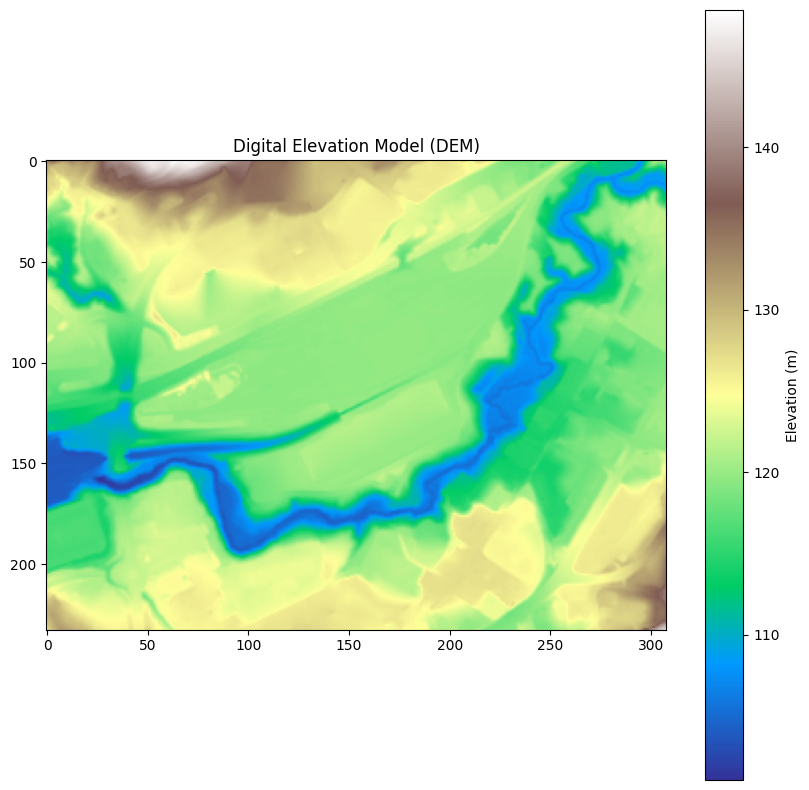

In [89]:
# Define the bounds for the area of interest
xmin, xmax, ymin, ymax = 268463.9, 270007.6, 6651396.2, 6652564.4
bounds = (xmin, xmax, ymin, ymax)

# Get the DEM data
dem_data = get_hoydedata(bounds)

# Plot the DEM
plt.figure(figsize=(10, 10))
plt.imshow(dem_data["full_array"], cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('Digital Elevation Model (DEM)')
plt.show()

### Understanding the Affine Transform

The **affine transform** is a mathematical mapping that converts pixel coordinates (row, col) in a raster to real-world geographic coordinates (x, y). It's stored as a 6-parameter transformation matrix.

#### The Affine Transform Equation

The transformation from pixel coordinates to geographic coordinates is given by:

$$
\begin{align}
x &= a \cdot col + b \cdot row + x_0 \\
y &= d \cdot col + e \cdot row + y_0
\end{align}
$$

Where:
- $(row, col)$ = pixel coordinates (starting from 0)
- $(x, y)$ = real-world geographic coordinates
- $a$ = pixel width (size of a pixel in the x-direction)
- $b$ = row rotation (typically 0 for north-up images)
- $x_0$ = x-coordinate of the upper-left corner
- $d$ = column rotation (typically 0 for north-up images)
- $e$ = pixel height (size of a pixel in the y-direction, typically negative)
- $y_0$ = y-coordinate of the upper-left corner

#### For a Standard North-Up Raster

In most cases (like our DEM), the raster is aligned with north being up, so the rotation terms are zero:

$$
\begin{align}
x &= a \cdot col + x_0 \\
y &= e \cdot row + y_0
\end{align}
$$

Where:
- $a > 0$ (pixel width, e.g., 5 meters)
- $e < 0$ (pixel height is negative because row increases downward while y increases upward)

#### Example

If our DEM has:
- Resolution: 5 meters
- Upper-left corner at: $(x_0, y_0) = (268463.9, 6652564.4)$

Then the affine parameters are:
- $a = 5$ (5 meters per pixel in x-direction)
- $b = 0$ (no rotation)
- $x_0 = 268463.9$ (starting x-coordinate)
- $d = 0$ (no rotation)
- $e = -5$ (5 meters per pixel in y-direction, negative because y decreases as row increases)
- $y_0 = 6652564.4$ (starting y-coordinate)

So to find the geographic coordinates of pixel at row=10, col=20:

$$
\begin{align}
x &= 5 \cdot 20 + 268463.9 = 268563.9 \\
y &= -5 \cdot 10 + 6652564.4 = 6652514.4
\end{align}
$$

#### The Inverse Transform

To go from geographic coordinates $(x, y)$ back to pixel coordinates $(row, col)$, we use the inverse:

$$
\begin{align}
col &= \frac{x - x_0}{a} \\
row &= \frac{y - y_0}{e}
\end{align}
$$

This is what `rasterio.transform.rowcol(transform, x, y)` does when we sample the DEM at specific points!

In [90]:
# Let's examine the affine transform from our DEM
transform = dem_data["profile"]["transform"]
print("Affine Transform:")
print(transform)
print("\nAffine parameters:")
print(f"a (pixel width): {transform.a}")
print(f"b (row rotation): {transform.b}")
print(f"x_0 (upper-left x): {transform.c}")
print(f"d (col rotation): {transform.d}")
print(f"e (pixel height): {transform.e}")
print(f"y_0 (upper-left y): {transform.f}")

# Example: Convert pixel (row=10, col=20) to geographic coordinates
row, col = 10, 20
x, y = rasterio.transform.xy(transform, row, col)
print(f"\nPixel ({row}, {col}) -> Geographic coordinates ({x:.2f}, {y:.2f})")

# Example: Convert geographic coordinates back to pixel
x_test, y_test = 268563.9, 6652514.4
row_back, col_back = rasterio.transform.rowcol(transform, x_test, y_test)
print(f"Geographic ({x_test}, {y_test}) -> Pixel ({row_back}, {col_back})")

# Verify the math manually
print("\nManual calculation:")
print(f"x = {transform.a} * {col} + {transform.c} = {transform.a * col + transform.c:.2f}")
print(f"y = {transform.e} * {row} + {transform.f} = {transform.e * row + transform.f:.2f}")

Affine Transform:
| 5.01, 0.00, 268463.63|
| 0.00,-5.01, 6652564.40|
| 0.00, 0.00, 1.00|

Affine parameters:
a (pixel width): 5.0137339055802
b (row rotation): 0.0
x_0 (upper-left x): 268463.63497854065
d (col rotation): 0.0
e (pixel height): -5.013733905580199
y_0 (upper-left y): 6652564.4

Pixel (10, 20) -> Geographic coordinates (268566.42, 6652511.76)
Geographic (268563.9, 6652514.4) -> Pixel (9, 19)

Manual calculation:
x = 5.0137339055802 * 20 + 268463.63497854065 = 268563.91
y = -5.013733905580199 * 10 + 6652564.4 = 6652514.26


In [91]:
print("All DEM data:", dem_data)
print("DEM profile:", dem_data['profile'])
print("DEM array shape and data:", dem_data['full_array'].shape, dem_data['full_array'])

All DEM data: {'profile': {'driver': 'GTiff', 'dtype': 'float32', 'nodata': -9999.0, 'width': 308, 'height': 233, 'count': 1, 'crs': CRS.from_wkt('PROJCS["ETRS89 / UTM zone 33N",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","25833"]]'), 'transform': Affine(5.0137339055802, 0.0, 268463.63497854065,
       0.0, -5.013733905580199, 6652564.4), 'blockxsize': 128, 'blockysize': 128, 'tiled': True, 'interleave': 'band'}, 'full_array': array([[133.01712 , 134.32141 , 135.29283 

### Step 2: Define Source Points and Calculate Slopes

Now that we have the DEM, we need to implement the core logic of the terrain criteria analysis. This involves three main parts:

1.  **Get DEM Coordinates**: We need a function to convert the DEM from a 2D grid of elevation values into a list of 3D coordinates (x, y, z) for every pixel.
2.  **Set Source Point Elevation**: Our source points are initially 2D (x, y). We need to find their elevation (z-value) by sampling the DEM.
3.  **Compute Slope**: This is the main calculation. For every pixel in the DEM, we'll calculate the slope between it and all of the source points, keeping the maximum slope value. The slope is calculated as the ratio of vertical height difference to horizontal distance.

In [92]:
def dem_coordinates(dem_array: np.ndarray, dem_transform: rasterio.transform.Affine) -> np.ndarray:
    """
    Converts a DEM array into a set of 3D coordinates (x, y, z).

    Args:
        dem_array (np.ndarray): The 2D NumPy array of the DEM.
        dem_transform (rasterio.transform.Affine): The affine transformation of the DEM.

    Returns:
        np.ndarray: A NumPy array of shape (n_pixels, 3) with the x, y, and z coordinates.
    """
    # Get the height (number of rows) and width (number of columns) of the DEM
    height, width = dem_array.shape
    
    # Create a 2D grid of column and row indices
    # cols will contain column numbers, rows will contain row numbers
    cols, rows = np.meshgrid(np.arange(width), np.arange(height))
    
    # Convert the row/column indices to real-world x, y coordinates using the affine transform
    xs, ys = rasterio.transform.xy(dem_transform, rows, cols)
    
    # Combine x, y coordinates with elevation (z) values into a single 3D coordinate array
    # flatten() converts the 2D arrays into 1D arrays
    # np.c_ concatenates arrays column-wise
    coords = np.c_[np.array(xs).flatten(), np.array(ys).flatten(), dem_array.flatten()]
    
    # Return the array of 3D coordinates
    return coords

In [93]:
# Test the dem_coordinates function
print("INPUT to dem_coordinates:")
print(f"  DEM shape: {dem_data['full_array'].shape}")
print(f"  DEM sample values (first 5x5):\n{dem_data['full_array'][:5, :5]}")
print(f"  Transform: {dem_data['profile']['transform']}")

# Call the function
dem_coords = dem_coordinates(dem_data["full_array"], dem_data["profile"]["transform"])

print("\nOUTPUT from dem_coordinates:")
print(f"  Output shape: {dem_coords.shape}")
print(f"  First 5 coordinates (x, y, z):\n{dem_coords[:5]}")
print(f"  Last 5 coordinates (x, y, z):\n{dem_coords[-5:]}")

INPUT to dem_coordinates:
  DEM shape: (233, 308)
  DEM sample values (first 5x5):
[[133.01712 134.32141 135.29283 135.5649  135.1736 ]
 [132.37906 132.87675 133.20807 133.09299 132.35934]
 [131.06512 131.21689 130.80191 130.40593 129.95311]
 [130.65724 130.20074 129.41267 129.44392 129.3602 ]
 [131.01842 130.11473 128.43254 128.49687 128.82674]]
  Transform: | 5.01, 0.00, 268463.63|
| 0.00,-5.01, 6652564.40|
| 0.00, 0.00, 1.00|

OUTPUT from dem_coordinates:
  Output shape: (71764, 3)
  First 5 coordinates (x, y, z):
[[2.68466142e+05 6.65256189e+06 1.33017120e+02]
 [2.68471156e+05 6.65256189e+06 1.34321411e+02]
 [2.68476169e+05 6.65256189e+06 1.35292831e+02]
 [2.68481183e+05 6.65256189e+06 1.35564896e+02]
 [2.68486197e+05 6.65256189e+06 1.35173599e+02]]
  Last 5 coordinates (x, y, z):
[[2.69985303e+05 6.65139871e+06 1.42319458e+02]
 [2.69990317e+05 6.65139871e+06 1.43338562e+02]
 [2.69995331e+05 6.65139871e+06 1.44094955e+02]
 [2.70000344e+05 6.65139871e+06 1.44719543e+02]
 [2.70005358

In [94]:
def set_z_from_raster(points_xy: np.ndarray, dem_data: dict) -> np.ndarray:
    """
    Assigns elevation values (z) to a set of 2D points (x, y) by sampling a DEM.

    Args:
        points_xy (np.ndarray): A NumPy array of shape (n_points, 2) with the x, y coordinates.
        dem_data (dict): The dictionary returned by `get_hoydedata`, containing the DEM and its profile.

    Returns:
        np.ndarray: A NumPy array of shape (n_points, 3) with the x, y, and z coordinates.
    """
    # Extract the DEM elevation array from the data dictionary
    dem_array = dem_data["full_array"]
    
    # Extract the affine transform from the profile
    transform = dem_data["profile"]["transform"]
    
    # Extract the nodata value from the profile
    nodata = dem_data["profile"]["nodata"]
    
    # Convert each (x, y) coordinate to pixel row and column indices
    # rasterio.transform.rowcol returns (row, col) for each (x, y) point
    indices = np.array([rasterio.transform.rowcol(transform, x, y) for x, y in points_xy])
    
    # Sample the DEM array at the calculated indices to get elevation values
    # For each (row, col) pair, we get the corresponding elevation
    z_values = np.array([dem_array[row, col] for row, col in indices])
    
    # Create a boolean mask to filter out points that fall on nodata pixels
    valid_mask = z_values != nodata
    
    # Combine the x, y coordinates with the z values, then filter by the valid mask
    # This removes any points that had nodata elevations
    return np.c_[points_xy, z_values][valid_mask]

In [95]:
# Define source points (from the original notebook)
source_points_xy = np.array([
    (268883.5400622159, 6651785.961672257), (268917.3041989159, 6651614.686395486),
    (268952.34858209593, 6651598.08903631), (269098.9750438174, 6651692.086224091),
    (269136.0121169521, 6651688.541504248), (269187.3338556726, 6651662.554160272),
    (269266.9063958938, 6651685.158933432), (269327.31869611563, 6651689.869289508),
    (269385.2269397425, 6651692.168949791), (269430.1044651593, 6651718.1729600765),
    (269417.70676140685, 6651750.211168494), (269417.9726969357, 6651774.200699851),
    (269471.1996794914, 6651798.455341154), (269514.28554422176, 6651813.7414565245),
    (269552.6144975672, 6651849.758094928), (269566.83348302596, 6651865.730493411),
    (269573.36843977927, 6651894.129818862)
])

print("INPUT to set_z_from_raster:")
print(f"  Source points shape: {source_points_xy.shape}")
print(f"  First 3 source points (x, y):\n{source_points_xy[:3]}")
print(f"  DEM nodata value: {dem_data['profile']['nodata']}")

# Call the function
source_points_3d = set_z_from_raster(source_points_xy, dem_data)

print("\nOUTPUT from set_z_from_raster:")
print(f"  Output shape: {source_points_3d.shape}")
print(f"  All source points with elevations (x, y, z):\n{source_points_3d}")

INPUT to set_z_from_raster:
  Source points shape: (17, 2)
  First 3 source points (x, y):
[[ 268883.54006222 6651785.96167226]
 [ 268917.30419892 6651614.68639549]
 [ 268952.3485821  6651598.08903631]]
  DEM nodata value: -9999.0

OUTPUT from set_z_from_raster:
  Output shape: (17, 3)
  All source points with elevations (x, y, z):
[[2.68883540e+05 6.65178596e+06 1.04436211e+02]
 [2.68917304e+05 6.65161469e+06 1.06245758e+02]
 [2.68952349e+05 6.65159809e+06 1.04109497e+02]
 [2.69098975e+05 6.65169209e+06 1.05677582e+02]
 [2.69136012e+05 6.65168854e+06 1.04369164e+02]
 [2.69187334e+05 6.65166255e+06 1.04610168e+02]
 [2.69266906e+05 6.65168516e+06 1.05498367e+02]
 [2.69327319e+05 6.65168987e+06 1.04789749e+02]
 [2.69385227e+05 6.65169217e+06 1.05853279e+02]
 [2.69430104e+05 6.65171817e+06 1.05292625e+02]
 [2.69417707e+05 6.65175021e+06 1.05890556e+02]
 [2.69417973e+05 6.65177420e+06 1.06160133e+02]
 [2.69471200e+05 6.65179846e+06 1.05768494e+02]
 [2.69514286e+05 6.65181374e+06 1.06154274

In [96]:
def compute_slope(coords: np.ndarray, points: np.ndarray, h_min: float = 5, nodata: int = -9999) -> np.ndarray:
    """
    Computes the maximum slope from each DEM coordinate to a set of source points.

    Args:
        coords (np.ndarray): The 3D coordinates of the DEM pixels.
        points (np.ndarray): The 3D coordinates of the source points.
        h_min (float, optional): The minimum height difference to consider for slope calculation. Defaults to 5.
        nodata (int, optional): The value to use for no data. Defaults to -9999.

    Returns:
        np.ndarray: An array of the maximum slope values for each DEM coordinate.
    """
    # Suppress warnings that might occur during division operations
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Extract the x, y coordinates (first two columns) from the DEM coordinates
        xy_1 = coords[:, :2]
        
        # Extract the x, y coordinates (first two columns) from the source points
        xy_2 = points[:, :2]
        
        # Extract the z (elevation) values from the DEM coordinates
        z1 = coords[:, -1]
        
        # Extract the z (elevation) values from the source points
        z2 = points[:, -1]
        
        # Compute the distance matrix: horizontal distance between each DEM pixel and each source point
        # Result shape: (n_dem_pixels, n_source_points)
        distance_mtx = distance_matrix(xy_1, xy_2)
        
        # Compute the height difference matrix: vertical difference between each DEM pixel and each source point
        # z1[:, np.newaxis] converts z1 from shape (n,) to (n, 1) for broadcasting
        # Result shape: (n_dem_pixels, n_source_points)
        height_mtx = z1[:, np.newaxis] - z2
        
        # Calculate the slope ratio: height difference divided by horizontal distance
        # This gives the tangent of the slope angle (rise over run)
        hl_ratio = height_mtx / distance_mtx
        
        # Set slopes to nodata where the height difference is less than the minimum threshold
        # This prevents calculating slopes for very small height differences
        hl_ratio[height_mtx < h_min] = nodata
        
        # For each DEM pixel, find the maximum slope across all source points
        # axis=1 means we find the maximum along the source points dimension
        max_slope = np.max(hl_ratio, axis=1)

        # Return the array of maximum slopes
        return max_slope

In [97]:
print("INPUT to compute_slope:")
print(f"  DEM coordinates shape: {dem_coords.shape}")
print(f"  Source points shape: {source_points_3d.shape}")
print(f"  h_min: 5")
print(f"  Sample DEM coords (first 3):\n{dem_coords[:3]}")
print(f"  Sample source points (first 3):\n{source_points_3d[:3]}")

# Call the function
slope_map = compute_slope(dem_coords, source_points_3d, h_min=5)

print("\nOUTPUT from compute_slope:")
print(f"  Output shape: {slope_map.shape}")
print(f"  Min slope: {slope_map.min():.4f}")
print(f"  Max slope: {slope_map.max():.4f}")
print(f"  Mean slope: {slope_map.mean():.4f}")
print(f"  First 10 slope values: {slope_map[:10]}")

INPUT to compute_slope:
  DEM coordinates shape: (71764, 3)
  Source points shape: (17, 3)
  h_min: 5
  Sample DEM coords (first 3):
[[2.68466142e+05 6.65256189e+06 1.33017120e+02]
 [2.68471156e+05 6.65256189e+06 1.34321411e+02]
 [2.68476169e+05 6.65256189e+06 1.35292831e+02]]
  Sample source points (first 3):
[[2.68883540e+05 6.65178596e+06 1.04436211e+02]
 [2.68917304e+05 6.65161469e+06 1.06245758e+02]
 [2.68952349e+05 6.65159809e+06 1.04109497e+02]]

OUTPUT from compute_slope:
  Output shape: (71764,)
  Min slope: -9999.0000
  Max slope: 0.6833
  Mean slope: -761.3876
  First 10 slope values: [0.03243873 0.03401033 0.03520967 0.03561437 0.03525933 0.03450633
 0.03351902 0.03273289 0.0323098  0.0325779 ]


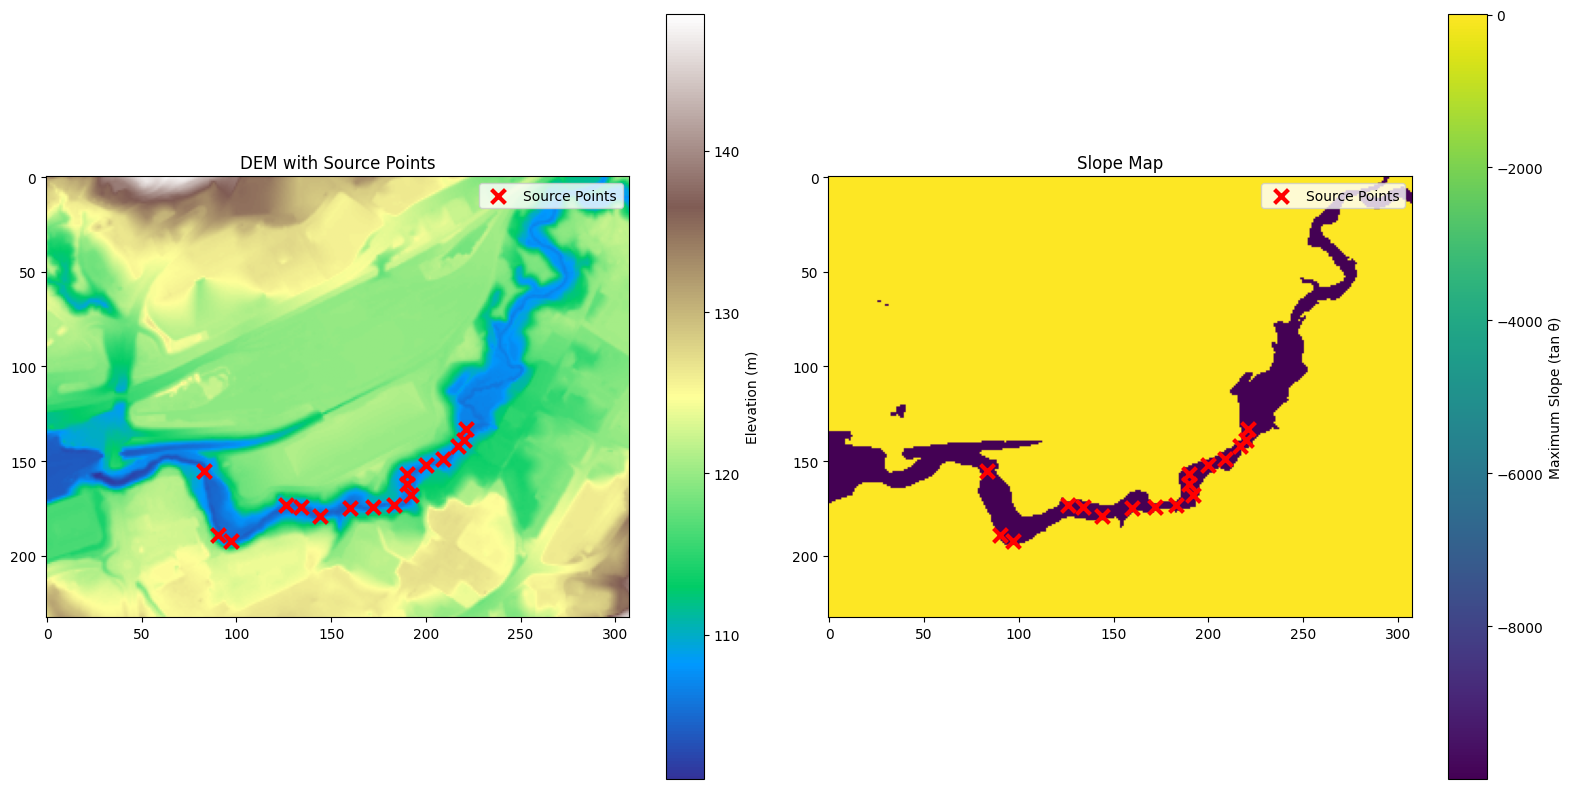

Final slope map shape: (233, 308)


In [98]:
# Reshape the slope map to match the DEM dimensions and visualize
slope_map_2d = slope_map.reshape(dem_data["full_array"].shape)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: DEM with source points
ax1 = axes[0]
dem_plot = ax1.imshow(dem_data["full_array"], cmap='terrain')
plt.colorbar(dem_plot, ax=ax1, label='Elevation (m)')

# Overlay source points (convert to pixel coordinates)
transform = dem_data["profile"]["transform"]
source_rows = []
source_cols = []
for x, y in source_points_xy:
    row, col = rasterio.transform.rowcol(transform, x, y)
    source_rows.append(row)
    source_cols.append(col)

ax1.scatter(source_cols, source_rows, c='red', s=100, marker='x', linewidths=3, label='Source Points')
ax1.set_title('DEM with Source Points')
ax1.legend()

# Plot 2: Slope map with source points
ax2 = axes[1]
slope_plot = ax2.imshow(slope_map_2d, cmap='viridis', vmax=0.3)
plt.colorbar(slope_plot, ax=ax2, label='Maximum Slope (tan θ)')
ax2.scatter(source_cols, source_rows, c='red', s=100, marker='x', linewidths=3, label='Source Points')
ax2.set_title('Slope Map')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final slope map shape: {slope_map_2d.shape}")

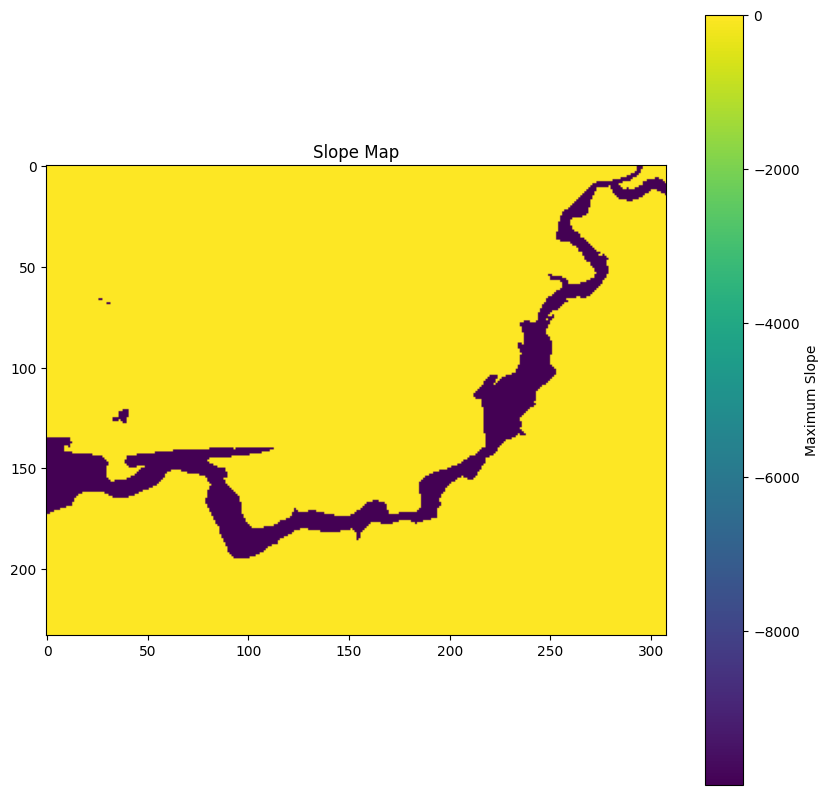

In [99]:
# Define source points (from the original notebook)
source_points_xy = np.array([
    (268883.5400622159, 6651785.961672257), (268917.3041989159, 6651614.686395486),
    (268952.34858209593, 6651598.08903631), (269098.9750438174, 6651692.086224091),
    (269136.0121169521, 6651688.541504248), (269187.3338556726, 6651662.554160272),
    (269266.9063958938, 6651685.158933432), (269327.31869611563, 6651689.869289508),
    (269385.2269397425, 6651692.168949791), (269430.1044651593, 6651718.1729600765),
    (269417.70676140685, 6651750.211168494), (269417.9726969357, 6651774.200699851),
    (269471.1996794914, 6651798.455341154), (269514.28554422176, 6651813.7414565245),
    (269552.6144975672, 6651849.758094928), (269566.83348302596, 6651865.730493411),
    (269573.36843977927, 6651894.129818862)
])

# Get the 3D coordinates for the DEM
dem_coords = dem_coordinates(dem_data["full_array"], dem_data["profile"]["transform"])

# Get the 3D coordinates for the source points
source_points_3d = set_z_from_raster(source_points_xy, dem_data)

# Compute the slopes
slope_map = compute_slope(dem_coords, source_points_3d)

# Reshape the slope map to match the DEM dimensions
slope_map_2d = slope_map.reshape(dem_data["full_array"].shape)

# Plot the slope map
plt.figure(figsize=(10, 10))
plt.imshow(slope_map_2d, cmap='viridis', vmax=0.3) # vmax is used to better visualize the slopes
plt.colorbar(label='Maximum Slope')
plt.title('Slope Map')
plt.show()

In [100]:
dem_coords

array([[2.68466142e+05, 6.65256189e+06, 1.33017120e+02],
       [2.68471156e+05, 6.65256189e+06, 1.34321411e+02],
       [2.68476169e+05, 6.65256189e+06, 1.35292831e+02],
       ...,
       [2.69995331e+05, 6.65139871e+06, 1.44094955e+02],
       [2.70000344e+05, 6.65139871e+06, 1.44719543e+02],
       [2.70005358e+05, 6.65139871e+06, 1.45230972e+02]])